In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

class CANClassificationDataset(Dataset):
    def __init__(self, sequences, labels):
        """
        sequences shape: (Samples, Window_Size, 64)
        labels shape: (Samples, 64) 
        """
        # Store the lightweight numpy arrays directly
        self.X = sequences
        self.y = labels

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Convert to PyTorch tensors dynamically, one batch at a time
        x_tensor = torch.tensor(self.X[idx], dtype=torch.float32)
        y_tensor = torch.tensor(self.y[idx], dtype=torch.long)
        return x_tensor, y_tensor

def get_labeled_dataloaders(file_path, labels_dict, window_size=200, window_stride=10, batch_size=256):
    df = pd.read_csv(file_path, sep='\s+', header=None, names=['timestamp', 'bus', 'raw_frame'])
    
    all_x = []
    all_y = []
    
    def hex_to_bit_array(hex_str):
        # Converts hex payload to 64 individual bits
        binary_str = bin(int(hex_str, 16))[2:].zfill(64)
        return np.array([int(b) for b in binary_str], dtype=np.int8)

    for target_id, bit_labels in labels_dict.items():
        # Filter for specific CAN ID
        df_target = df[df['raw_frame'].str.contains(f"^{target_id}#")].copy()
        if len(df_target) < window_size: continue
        
        payloads = df_target['raw_frame'].str.split('#').str[1]
        bit_data = np.stack(payloads.apply(hex_to_bit_array).values) # Shape (N_frames, 64)

        # Create Strided Windows 
        # New Shape: (Number_of_Windows, Window_Size, 64)
        shape = ((bit_data.shape[0] - window_size) // window_stride + 1, window_size, 64)
        strides = (bit_data.strides[0] * window_stride, bit_data.strides[0], bit_data.strides[1])
        windows = np.lib.stride_tricks.as_strided(bit_data, shape=shape, strides=strides) 

        # Map Labels
        # keep the 64 labels per window to match the 64-bit input width
        labels_array = np.array(bit_labels) # Shape (64,)
        #repeat labels for every window generated for this ID
        target_y = np.tile(labels_array, (windows.shape[0], 1)) 
        
        all_x.append(windows)
        all_y.append(target_y)
    
    X = np.concatenate(all_x, axis=0)
    y = np.concatenate(all_y, axis=0)
    
    train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.2, shuffle=True)
    # print(train_x)
    train_dl = DataLoader(CANClassificationDataset(train_x, train_y), batch_size=batch_size, shuffle=True)
    test_dl = DataLoader(CANClassificationDataset(test_x, test_y), batch_size=batch_size, shuffle=False)
    
    print(f"Total Windows: {len(y)} | Input Shape: {X.shape[1:]}")
    return train_dl, test_dl


In [20]:
Impreza_Ground_Labels = {

    '002': [
    # Byte 1 (sensor lsb)
    3, 3, 3, 3, 3, 3, 3, 3,
    # Byte 2 (sensor msb)
    3, 3, 3, 3, 3, 3, 3, 3,
    # Byte 3 (Spare)
    0, 0, 0, 0, 0, 0, 0, 0,
    # Byte 4 (counter and spare)
    0, 0, 0, 0, 2, 2, 2, 1,
    # Byte 5 (bit flag and Checksum)
    4, 4, 4, 4, 4, 4, 4, 4,
    # Byte 6 (Spare)
    0, 0, 0, 0, 0, 0, 0, 0,
    # Byte 7 (Spare)
    0, 0, 0, 0, 0, 0, 0, 0,
    # Byte 8 (static)
    0, 0, 0, 0, 0, 0, 0, 0],

    '141': [
    # Byte 1 (sensor)
    3, 3, 3, 3, 3, 3, 3, 3,
    # Byte 2 (4 spare sensor msb)
    0, 0, 0, 0, 3, 3, 3, 3,
    # Byte 3 (sensor lsb)
    3, 3, 3, 3, 3, 3, 3, 3,
    # Byte 4 (4 spare sensor msb)
    0, 0, 0, 0, 3, 3, 3, 3,
    # Byte 5 (sensor lsb)
    3, 3, 3, 3, 3, 3, 3, 3,
    # Byte 6 (bit flags)
    1, 0, 0, 0, 3, 3, 3, 3,
    0, 1, 1, 1, 1, 0, 0, 0,
    0, 0, 0, 1, 1, 0, 0, 0
    ],


    '140': [
    # Byte 1: 1 Static, 7-bit Sensor
    0, 3, 3, 3, 3, 3, 3, 3,
    # Byte 2: 4 Static, 4-bit Counter
    0, 0, 0, 0, 2, 2, 2, 2,
    # Byte 3: 8-bit Fast Sensor
    3, 3, 3, 3, 3, 3, 3, 3,
    # Byte 4: Mixed (Static, Flag, Static, 3-bit State, Static)
    0, 1, 0, 0, 3, 3, 3, 0,
    # Byte 5: 8-bit Sensor
    3, 3, 3, 3, 3, 3, 3, 3,
    # Byte 6: 1 Static, 7-bit Sensor
    0, 3, 3, 3, 3, 3, 3, 3,
    # Byte 7: 8-bit Sensor
    3, 3, 3, 3, 3, 3, 3, 3,
    # Byte 8: Mostly Static, Flags on 58 and 63
    0, 0, 1, 0, 0, 0, 0, 1
    ],

    '148': [
    # Byte 1: 4 Static 4 bit
    0, 0, 0, 0, 1, 1, 1, 1,
    # Byte 2: 4 Static 4-bit counter
    0, 0, 0, 0, 2, 2, 2, 2,
    # Byte 3: sensor
    3, 3, 3, 3, 3, 3, 3, 3,
    0, 0, 0, 0, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0,
    1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 0, 0, 0, 0, 0, 0
    ],

    '149': [
    # Byte 1: 4-bit Counter, 4 Static
    3, 3, 3, 3, 3, 3, 3, 3,
    0, 0, 0, 0, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0,
    3, 3, 3, 3, 3, 3, 3, 3,
    0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0
    ],

    
    '15A': [
    # Byte 1 (2-3 bit flag 4-7 counter)
    0, 0, 1, 1, 2, 2, 2, 2,
    # Byte 2 
    1, 0, 1, 1, 1, 0, 0, 0,
    # Byte 3 
    0, 0, 0, 0, 1, 1, 0, 1,
    # Byte 4 
    0, 0, 0, 0, 0, 0, 0, 0,
    # Byte 5 
    0, 0, 0, 0, 0, 0, 0, 0,
    # Byte 6 (bit flags)
    0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 1, 1, 1, 0, 1, 0,
    0, 0, 0, 0, 1, 0, 1, 1,
    ],

    '0D0': [
    # Bytes 1 & 2: 16-bit Sensor
    3, 3, 3, 3, 3, 3, 3, 3,
    3, 3, 3, 3, 3, 3, 3, 3,
    # Bytes 3 & 4: 16-bit Sensor
    3, 3, 3, 3, 3, 3, 3, 3,
    3, 3, 3, 3, 3, 3, 3, 3,
    # Byte 5: 8-bit Sensor / Slow State
    3, 3, 3, 3, 3, 3, 3, 3,
    # Byte 6: 2 Static Bits, 6 Bit Flags
    0, 0, 1, 1, 1, 1, 1, 1,
    # Bytes 7 & 8: 16-bit Checksum / Entropy
    4, 4, 4, 4, 4, 4, 4, 4,
    4, 4, 4, 4, 4, 4, 4, 4
    ],
    '378': [
    # Byte 1: 4-bit Counter, 4 Static
    2, 2, 2, 2, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0
    ],
    '280': [
    # Byte 1: 4 Static, 4-bit flags
    0, 0, 0, 0, 1, 1, 1, 1,
    # Byte 2: 4 Static, 4-bit Counter
    0, 0, 0, 0, 2, 2, 2, 2,
    0, 0, 0, 0, 1, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0,
    0, 1, 1, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0
    ],
}
    

In [21]:
log_path='logs/6_2012 Subaru Impreza/driving/6_driving_CAN.log'
train_dl, test_dl = get_labeled_dataloaders(log_path,Impreza_Ground_Labels )

Total Windows: 154464 | Input Shape: (200, 64)


In [22]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import pandas as pd

def get_global_bit_flips(file_path, target_id):
    """
    Reads the raw log file, extracts all payloads for a specific CAN ID,
    and calculates the total number of bit flips (0->1 or 1->0) across all frames.
    """
    df = pd.read_csv(file_path, sep='\s+', header=None, names=['timestamp', 'bus', 'raw_frame'])
    df_target = df[df['raw_frame'].str.contains(f"^{target_id}#")].copy()
    
    if len(df_target) < 2:
        return np.zeros(64) 
        
    payloads = df_target['raw_frame'].str.split('#').str[1]
    
    def hex_to_bit_array(hex_str):
        binary_str = bin(int(hex_str, 16))[2:].zfill(64)
        return np.array([int(b) for b in binary_str], dtype=np.int64)

    bit_data = np.stack(payloads.apply(hex_to_bit_array).values) 
    bit_flips = (bit_data[1:] != bit_data[:-1]).sum(axis=0)
    return bit_flips


def plot_labeled_window(window_tensor, bit_labels, can_id, global_flips):
    """
    Plots a CAN bit heatmap, a global bit-flip heatmap, and a color-coded label strip.
    """
    # 1. Prepare Main Window Data
    data = window_tensor.numpy() if hasattr(window_tensor, 'numpy') else np.array(window_tensor)
    time_steps, bits = data.shape 
    bit_flips_2d = global_flips.reshape(1, -1) 
    
    # 2. Setup figure with 3 Subplots
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 11), 
                                       gridspec_kw={'height_ratios': [10, 1, 1]},
                                       sharex=True)
    
    # 3. Plot the Main Bit Sequence (The Window)
    ax1.imshow(data, aspect='auto', cmap='binary', interpolation='nearest')
    ax1.set_title(f"Temporal Bit Sequence: ID {can_id}", fontsize=16, pad=20)
    ax1.set_ylabel(f"Time Steps (0-{time_steps})", fontsize=12)
    
    # 4. Plot the Label Strip (ax2)
    class_colors = ['#f2f2f2', '#e74c3c', '#2ecc71', '#3498db', '#f39c12']
    cmap_labels = mcolors.ListedColormap(class_colors)
    label_strip = np.array(bit_labels).reshape(1, -1)
    ax2.imshow(label_strip, aspect='auto', cmap=cmap_labels, vmin=0, vmax=4)
    ax2.set_yticks([]) 
    ax2.set_ylabel("Class\nLabels", fontsize=10, rotation=0, labelpad=25, va='center')
    
    # 5. Plot the Global Bit Flips (ax3) - CUSTOM COLORMAP
    # Create a gradient from Blue to Red
    cmap_flips = mcolors.LinearSegmentedColormap.from_list("blue_red", ["blue", "red"])
    # Force anything below our minimum (1) to be white
    cmap_flips.set_under("white")
    
    # Set vmin=1 so that 0 falls "under" the colormap and triggers the white fill.
    # We dynamically set vmax to the max bit flip count to scale the blue-to-red gradient properly.
    im_flips = ax3.imshow(bit_flips_2d, aspect='auto', cmap=cmap_flips, vmin=1, vmax=global_flips.max())

    from matplotlib.colors import LogNorm
    
    # Find the max flips, but force it to be at least 10 so LogNorm never crashes
    max_flips = global_flips.max()
    vmax_safe = max(max_flips, 10) 
    
    im_flips = ax3.imshow(
        bit_flips_2d, 
        aspect='auto', 
        cmap=cmap_flips, 
        norm=LogNorm(vmin=1, vmax=vmax_safe) # Use the safe ceiling
    )
    
    ax3.set_yticks([]) 
    ax3.set_xlabel("Bit Index (0-63)", fontsize=12) 
    ax3.set_ylabel("Global\nFlips", fontsize=10, rotation=0, labelpad=25, va='center')
    
    # 6. Align axes and add colorbar
    div1 = make_axes_locatable(ax1)
    cax1 = div1.append_axes("right", size="2%", pad=0.1)
    cax1.axis('off')

    div2 = make_axes_locatable(ax2)
    cax2 = div2.append_axes("right", size="2%", pad=0.1)
    cax2.axis('off') 

    div3 = make_axes_locatable(ax3)
    cax3 = div3.append_axes("right", size="2%", pad=0.1)
    
    # The `extend='min'` adds a nice visual pointer at the bottom of the colorbar indicating the white "0" value.
    cbar = fig.colorbar(im_flips, cax=cax3, extend='min')
    cbar.set_label('Total Flips\n(All Frames)', fontsize=10)

    # 7. Legend
    legend_elements = [
        Patch(facecolor=class_colors[0], label='0: Spare/Static'),
        Patch(facecolor=class_colors[1], label='1: Bit Flag'),
        Patch(facecolor=class_colors[2], label='2: Counter'),
        Patch(facecolor=class_colors[3], label='3: Sensor'),
        Patch(facecolor=class_colors[4], label='4: Checksum'),
    ]
    ax1.legend(handles=legend_elements, loc='lower right')

    ax3.set_xlim(-0.5, 63.5)
    ax3.set_xticks(range(0, 64, 4))
    
    plt.tight_layout()
    plt.show()

In [23]:
def get_single_window_for_id(file_path, target_id, window_size=50, seed=1669436):
    """Helper to grab a random contiguous window for a specific ID to plot."""
    df = pd.read_csv(file_path, sep='\s+', header=None, names=['timestamp', 'bus', 'raw_frame'])
    df_target = df[df['raw_frame'].str.contains(f"^{target_id}#")].copy()
    
    total_frames = len(df_target)
    
    if total_frames < window_size:
        print(f"Not enough data for ID {target_id}. Found {total_frames}, need {window_size}.")
        return None
        
    # --- NEW: Random Window Logic ---
    if seed is not None:
        np.random.seed(seed)
        
    # The highest index we can start at without running out of frames
    max_start_idx = total_frames - window_size
    
    # Pick a random starting row
    start_idx = np.random.randint(0, max_start_idx + 1) if max_start_idx > 0 else 0
    print(f"Extracting {window_size} frames starting from index {start_idx} (out of {total_frames} total)")
    
    # Slice the payloads from the random start index
    payloads = df_target['raw_frame'].str.split('#').str[1].iloc[start_idx : start_idx + window_size]
    
    def hex_to_bit_array(hex_str):
        binary_str = bin(int(hex_str, 16))[2:].zfill(64)
        return np.array([int(b) for b in binary_str], dtype=np.float32)

    return np.stack(payloads.apply(hex_to_bit_array).values)




346
Extracting 500 frames starting from index 106888 (out of 118730 total)


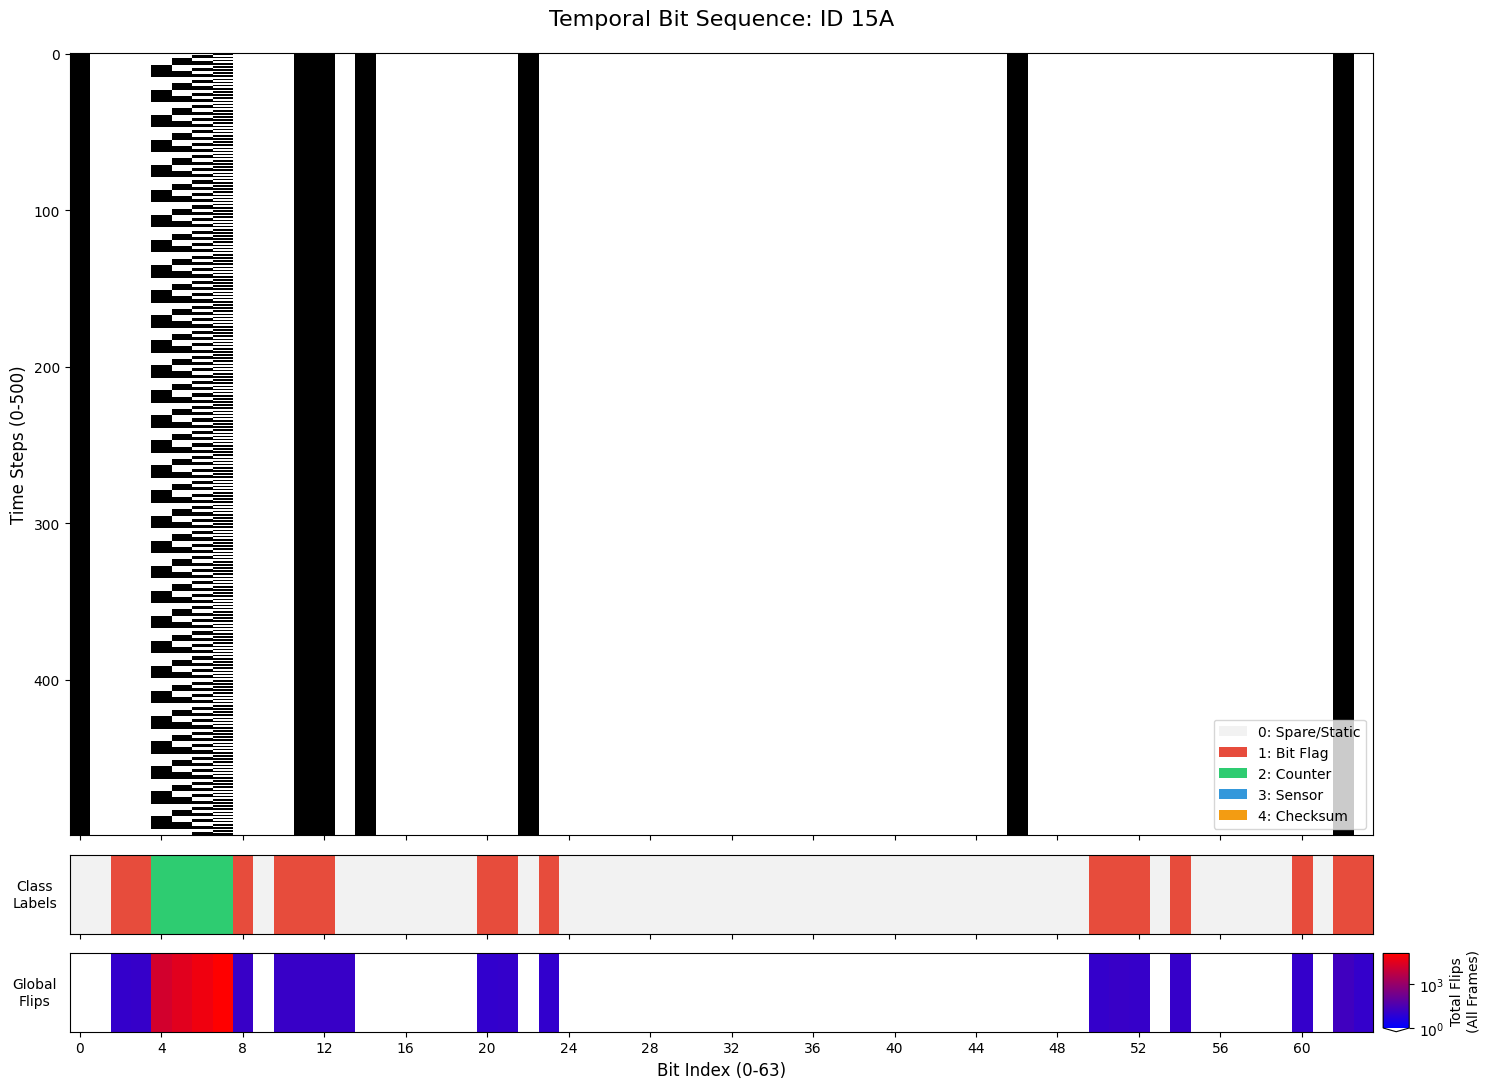

In [24]:
target_id = '15A' 
print(int(0x15A))
labels_list = Impreza_Ground_Labels[target_id]

window_tensor = get_single_window_for_id(log_path, target_id, window_size=500)

global_flips = get_global_bit_flips(log_path, target_id)

plot_labeled_window(window_tensor, labels_list, target_id, global_flips)

328
Extracting 500 frames starting from index 106888 (out of 237479 total)


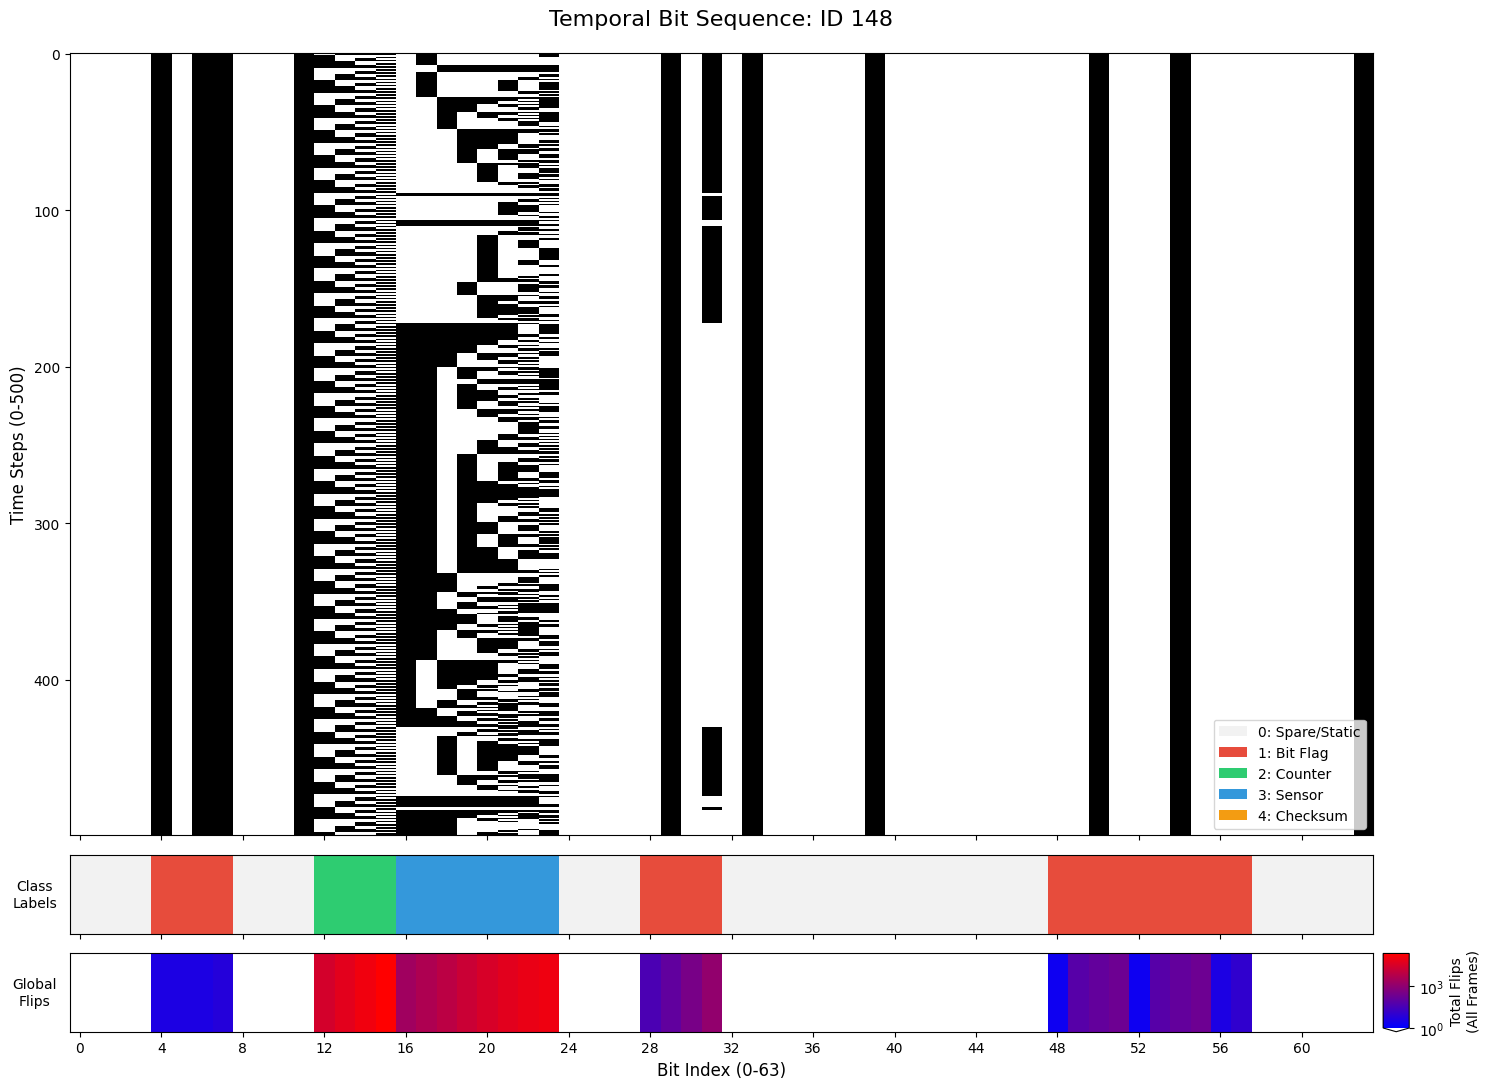

In [7]:
target_id = '148' 
print(int(0x148))
labels_list = Impreza_Ground_Labels[target_id]

window_tensor = get_single_window_for_id(log_path, target_id, window_size=500)

global_flips = get_global_bit_flips(log_path, target_id)

plot_labeled_window(window_tensor, labels_list, target_id, global_flips)

329
Extracting 3000 frames starting from index 106888 (out of 237479 total)


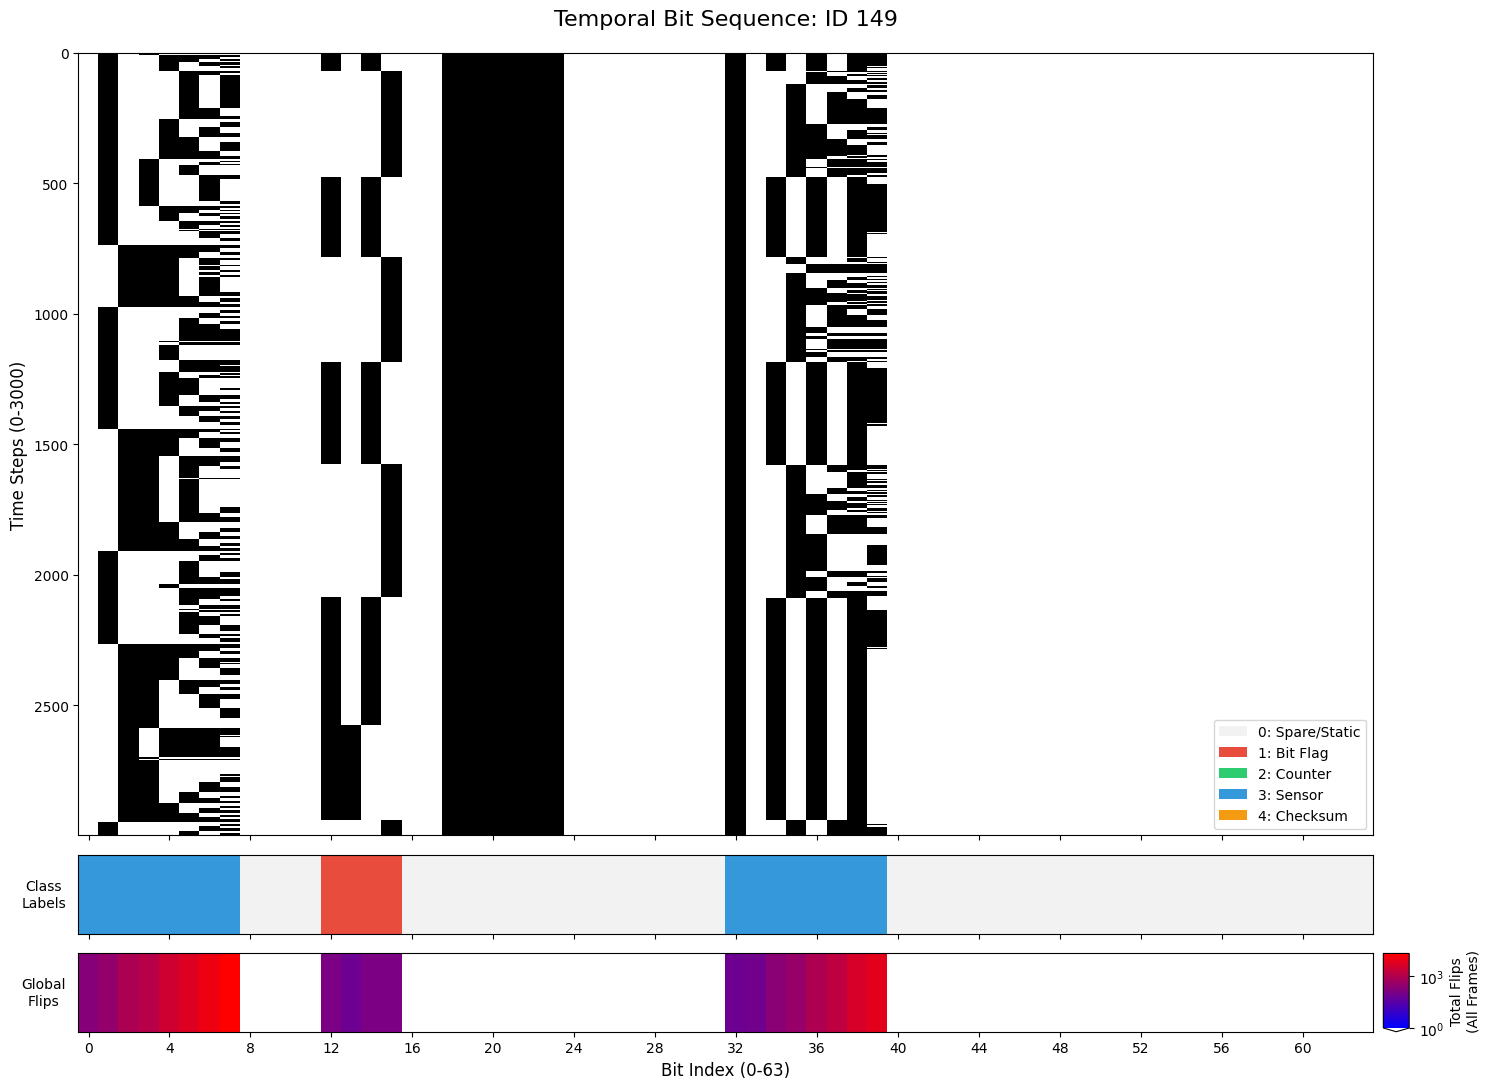

In [8]:
target_id = '149' 
print(int(0x149))
labels_list = Impreza_Ground_Labels[target_id]

window_tensor = get_single_window_for_id(log_path, target_id, window_size=3000)

global_flips = get_global_bit_flips(log_path, target_id)

plot_labeled_window(window_tensor, labels_list, target_id, global_flips)

Extracting 200 frames starting from index 106888 (out of 118916 total)


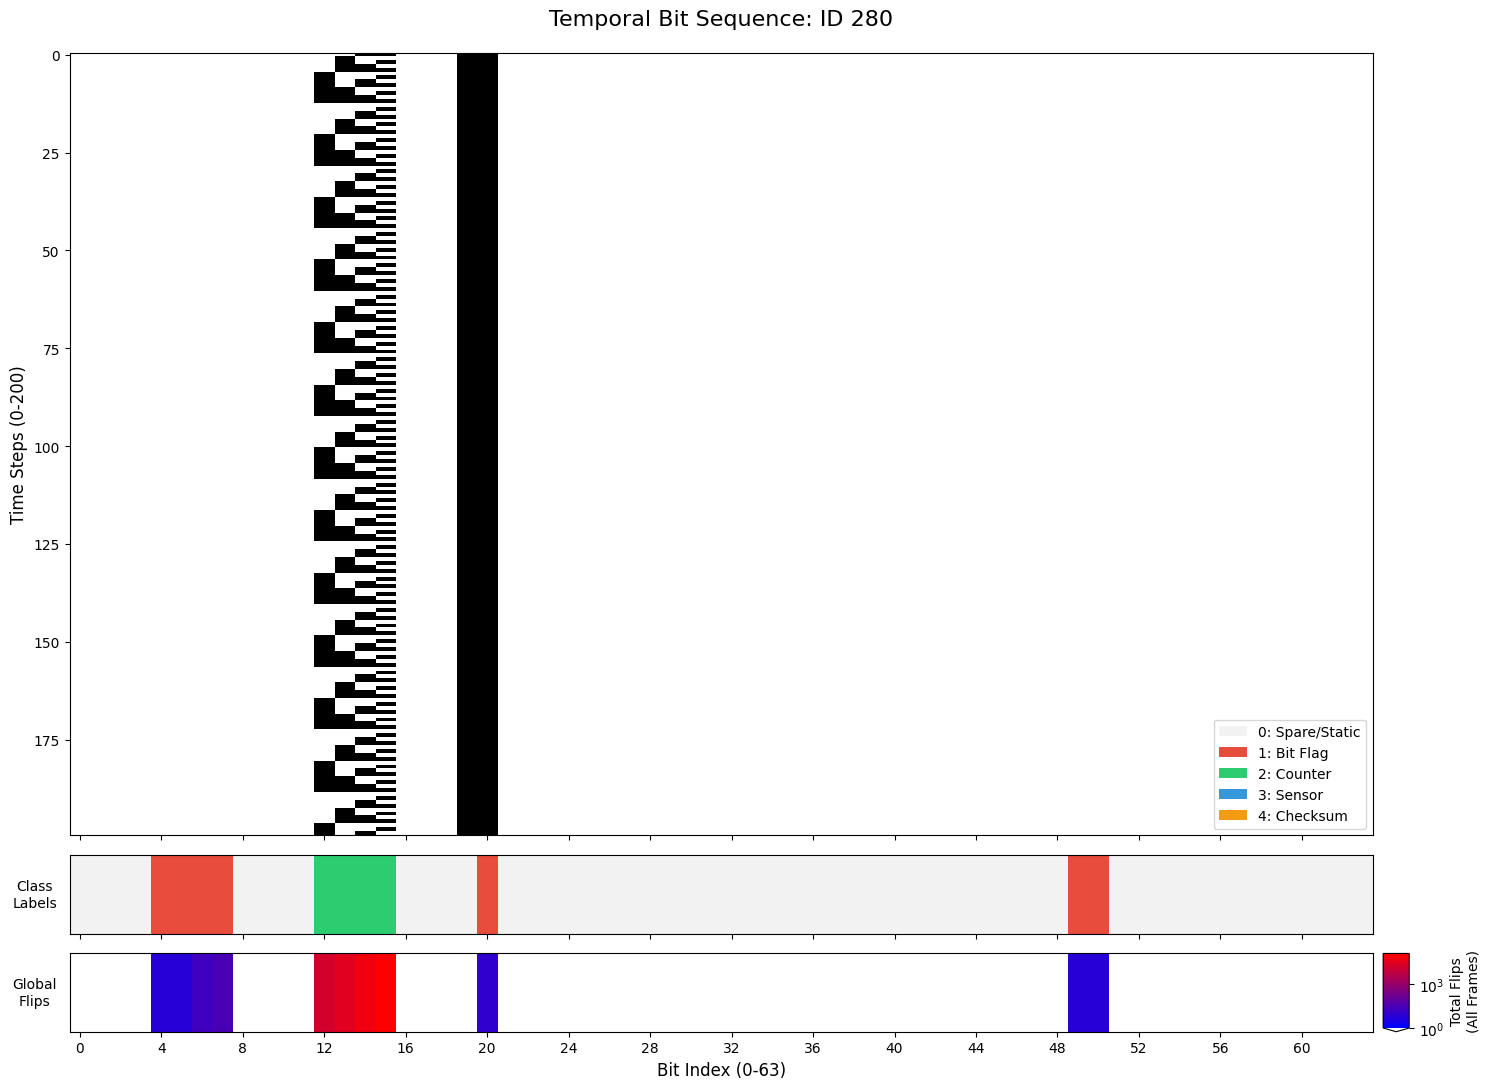

In [9]:
target_id = '280' 
labels_list = Impreza_Ground_Labels[target_id]

window_tensor = get_single_window_for_id(log_path, target_id, window_size=200)

global_flips = get_global_bit_flips(log_path, target_id)

plot_labeled_window(window_tensor, labels_list, target_id, global_flips)

Extracting 200 frames starting from index 106888 (out of 118702 total)


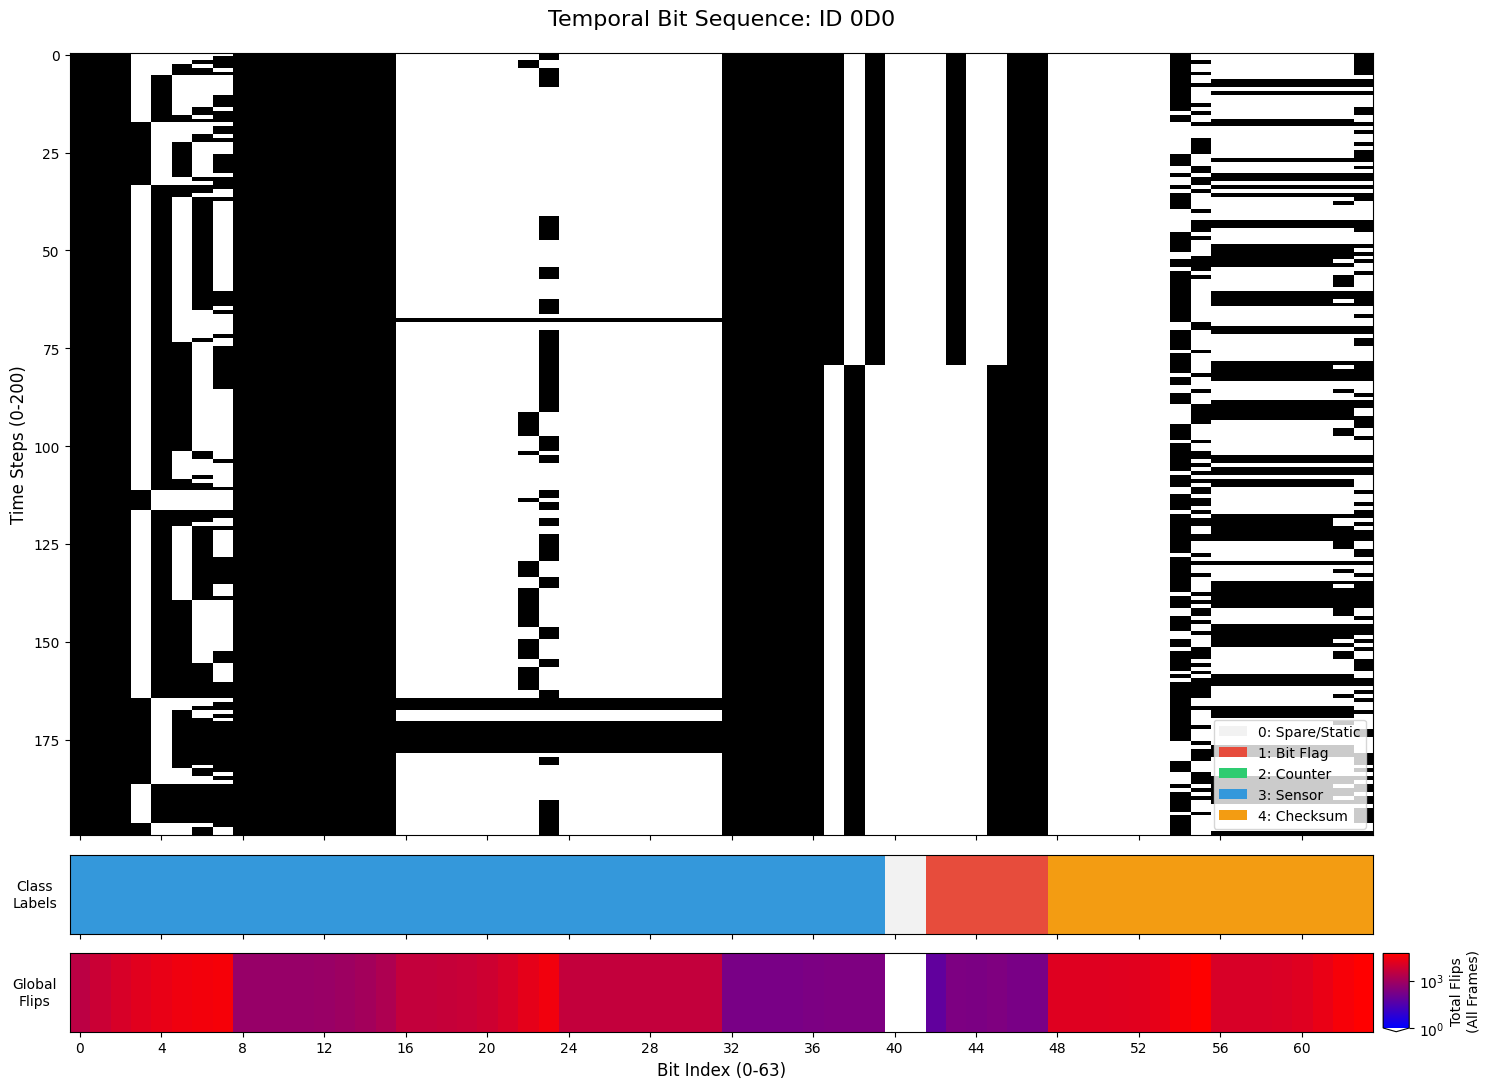

In [10]:
target_id = '0D0' 
labels_list = Impreza_Ground_Labels[target_id]

window_tensor = get_single_window_for_id(log_path, target_id, window_size=200)

global_flips = get_global_bit_flips(log_path, target_id)

plot_labeled_window(window_tensor, labels_list, target_id, global_flips)

Extracting 200 frames starting from index 106888 (out of 118702 total)


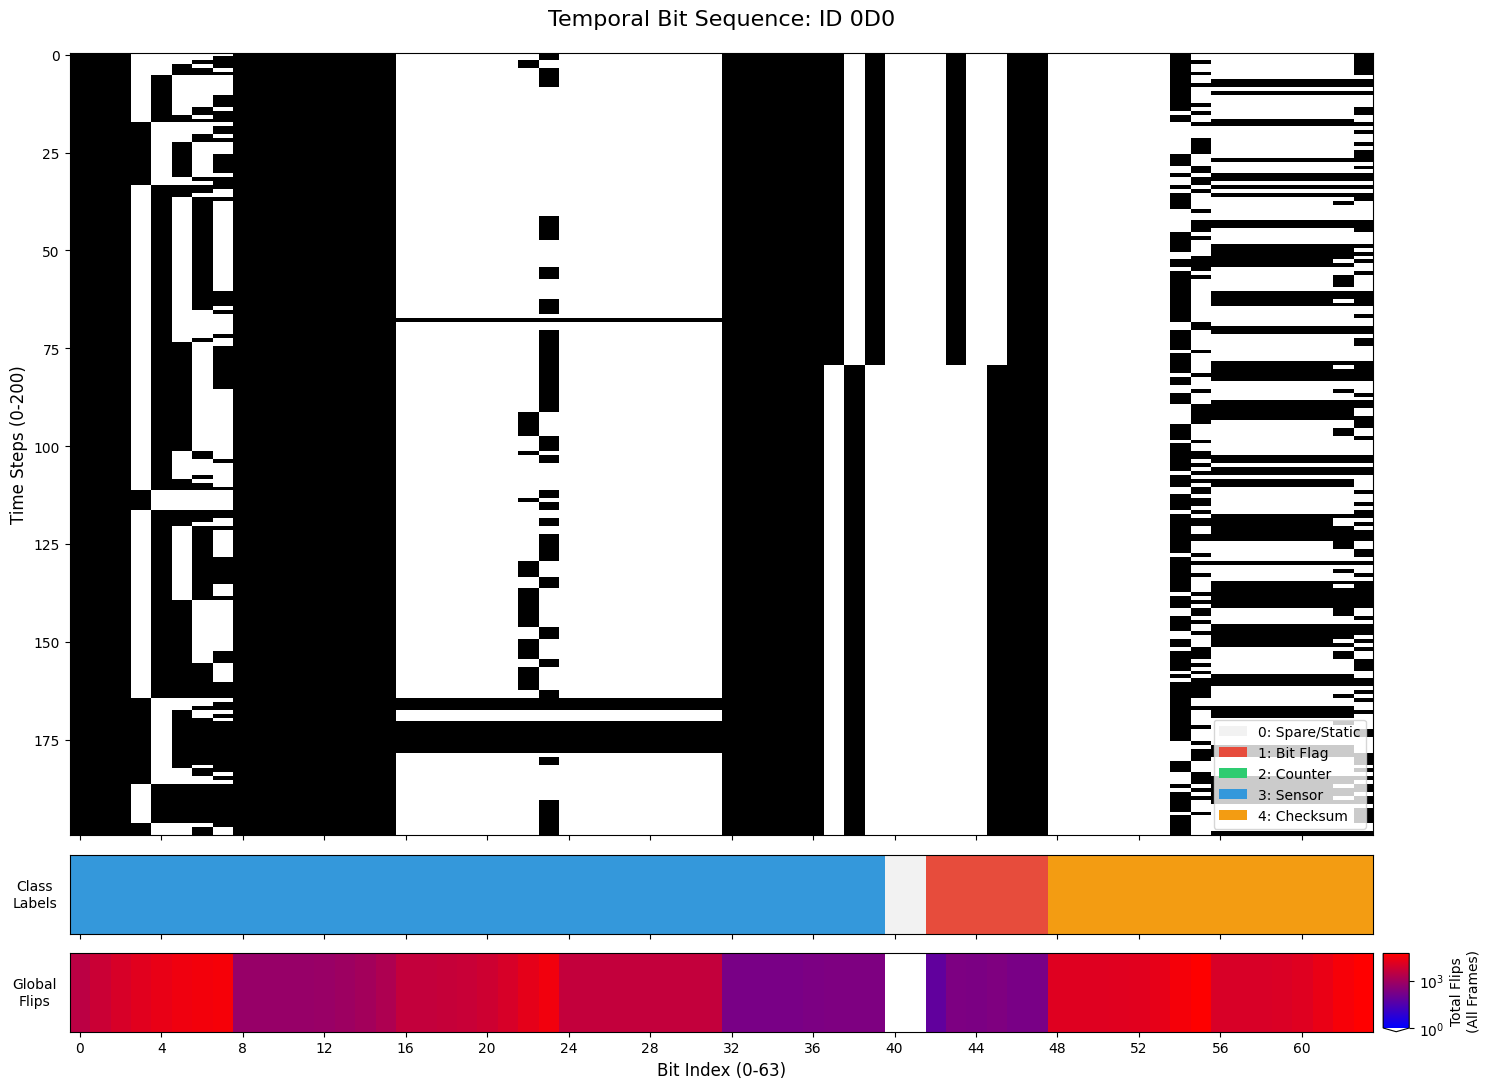

In [11]:
target_id = '0D0' 
labels_list = Impreza_Ground_Labels[target_id]

window_tensor = get_single_window_for_id(log_path, target_id, window_size=200)

# Get the global flips specifically for ID 378
global_flips = get_global_bit_flips(log_path, target_id)

plot_labeled_window(window_tensor, labels_list, target_id, global_flips)

Extracting 50 frames starting from index 106888 (out of 118916 total)


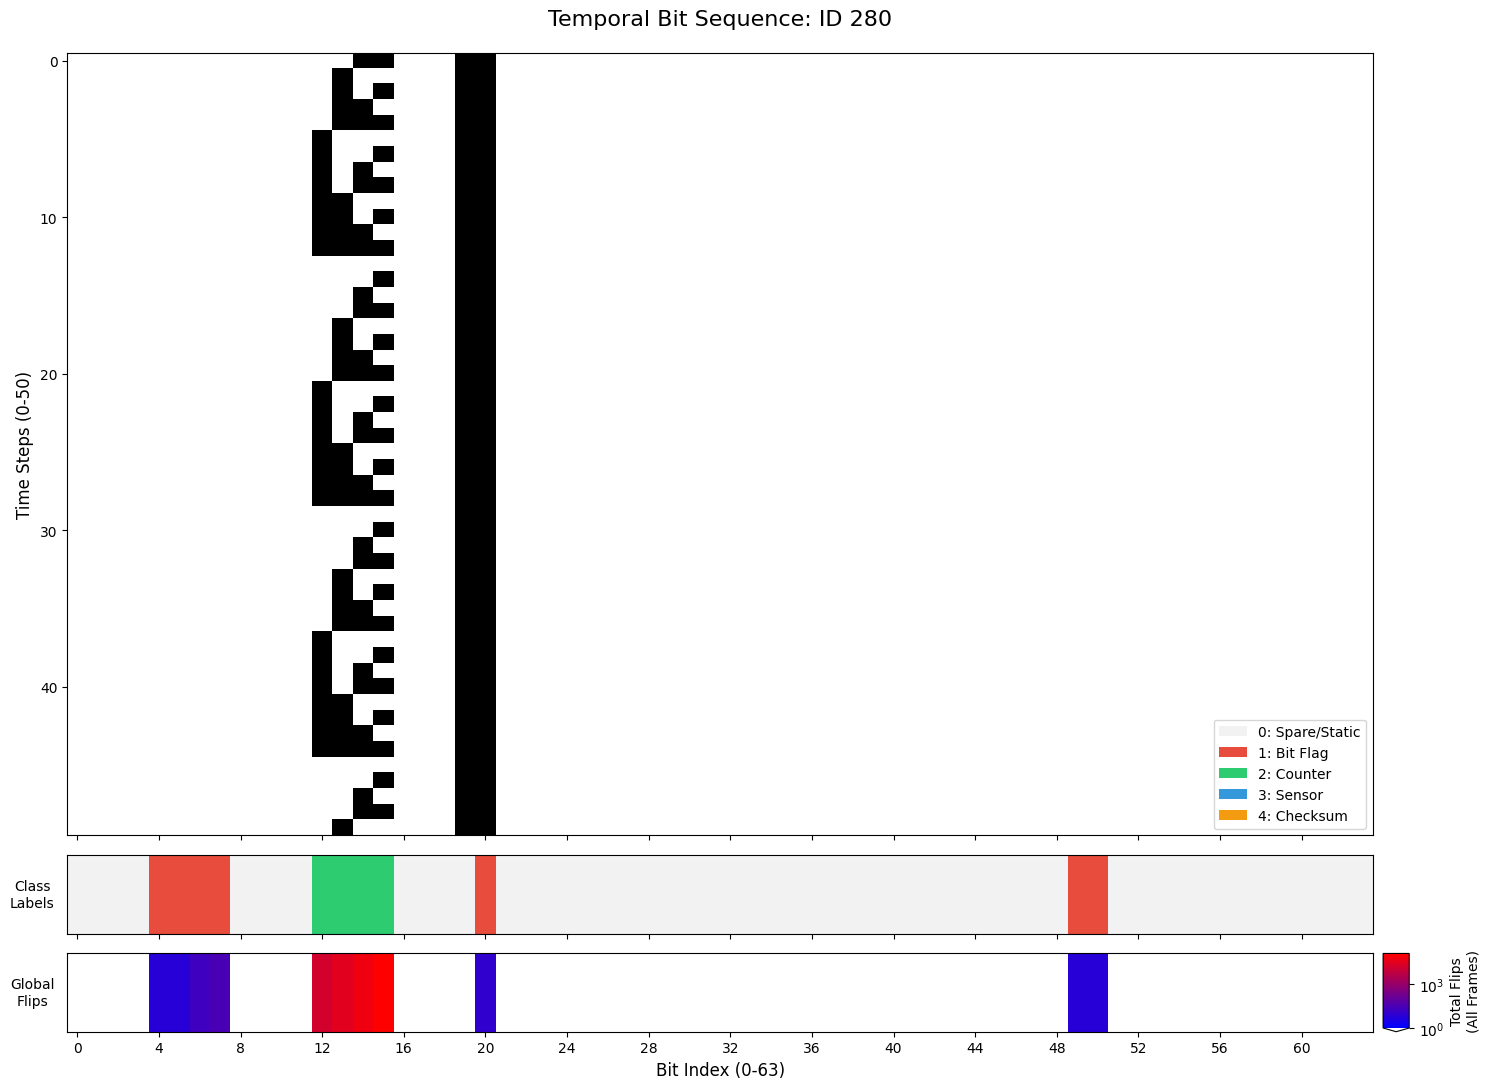

In [12]:
target_id = '280' 
labels_list = Impreza_Ground_Labels[target_id]

window_tensor = get_single_window_for_id(log_path, target_id)

global_flips = get_global_bit_flips(log_path, target_id)

plot_labeled_window(window_tensor, labels_list, target_id, global_flips)

In [13]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import DataLoader, random_split
# import numpy as np


# class CANLSTMClassifier(nn.Module):
#     def __init__(self, input_size=64, hidden_size=128, num_layers=2,
#                  num_classes=5, dropout=0.2, bidirectional=False):
#         super(CANLSTMClassifier, self).__init__()

#         self.hidden_size = hidden_size
#         self.num_layers = num_layers
#         self.bidirectional = bidirectional
#         self.num_directions = 2 if bidirectional else 1
#         self.num_classes = num_classes # Store for reshaping later

#         # LSTM layer
#         self.lstm = nn.LSTM(
#             input_size=input_size,
#             hidden_size=hidden_size,
#             num_layers=num_layers,
#             dropout=dropout if num_layers > 1 else 0,
#             bidirectional=bidirectional,
#             batch_first=True
#         )

#         # Map the final pooled hidden state to 64 bits * num_classes
#         self.fc = nn.Linear(hidden_size * self.num_directions, 64 * num_classes)

#         # Dropout layer
#         self.dropout = nn.Dropout(dropout)

#     def forward(self, x):
#         batch_size = x.size(0)

#         # Forward propagate LSTM
#         # Note: PyTorch handles h0 and c0 initialization automatically if omitted
#         _, (h_n, _) = self.lstm(x)

#         # Extract the final hidden state from the last LSTM layer
#         # This properly handles both standard and bidirectional states
#         if self.bidirectional:
#             # Concatenate the last forward state and last backward state
#             hidden = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1)
#         else:
#             hidden = h_n[-1, :, :]

#         # Apply dropout
#         hidden = self.dropout(hidden)

#         # Decode to predict classes for all 64 bits simultaneously
#         out = self.fc(hidden)  # Shape: (batch_size, 64 * num_classes)

#         # Reshape to (batch_size, 64, num_classes) for CrossEntropyLoss alignment
#         out = out.view(batch_size, 64, self.num_classes) 

#         return out

# def LSTM_baseline(dropout=False, lr=0.001, hidden_size=128, num_layers=2,
#                   bidirectional=False, num_classes=5):
#     """
#     Create an LSTM model for CAN bit classification

#     Args:
#         dropout (float or bool): Dropout rate (if False, no dropout)
#         lr (float): Learning rate
#         hidden_size (int): Number of features in LSTM hidden state
#         num_layers (int): Number of LSTM layers
#         bidirectional (bool): Whether to use bidirectional LSTM
#         num_classes (int): Number of output classes

#     Returns:
#         model: Initialized LSTM model
#         criterion: Loss function
#         optimizer: Optimizer
#     """
#     # Handle dropout parameter
#     dropout_rate = dropout if dropout is not False else 0.0

#     # Initialize model
#     model = CANLSTMClassifier(
#         input_size=64,
#         hidden_size=hidden_size,
#         num_layers=num_layers,
#         num_classes=num_classes,
#         dropout=dropout_rate,
#         bidirectional=bidirectional
#     )

#     # Define loss function (CrossEntropyLoss for multi-class classification)
#     criterion = nn.CrossEntropyLoss()

#     # Define optimizer
#     optimizer = optim.Adam(model.parameters(), lr=lr)

#     return model, criterion, optimizer

# def LSTM_training_loop(train_dl, val_size=0.2, epochs=50, dropout=False, lr=0.001,
#                       hidden_size=128, num_layers=2, bidirectional=False,
#                       num_classes=5, device=None, verbose=True):
#     """
#     Training loop for LSTM model on CAN data

#     Args:
#         train_dl: DataLoader containing training data
#         val_size (float): Proportion of data to use for validation
#         epochs (int): Number of training epochs
#         dropout (float or bool): Dropout rate
#         lr (float): Learning rate
#         hidden_size (int): LSTM hidden size
#         num_layers (int): Number of LSTM layers
#         bidirectional (bool): Whether to use bidirectional LSTM
#         num_classes (int): Number of output classes
#         device: Torch device to use (if None, auto-detect)
#         verbose (bool): Whether to print progress

#     Returns:
#         model: Trained model
#         train_losses: List of training losses per epoch
#         val_losses: List of validation losses per epoch
#         train_accs: List of training accuracies per epoch
#         val_accs: List of validation accuracies per epoch
#     """
#     # Set device
#     if device is None:
#         device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#     if verbose:
#         print(f"Using device: {device}")

#     # Get dataset from DataLoader
#     dataset = train_dl.dataset

#     # Split dataset into train and validation
#     val_size_abs = int(len(dataset) * val_size)
#     train_size_abs = len(dataset) - val_size_abs

#     train_dataset, val_dataset = random_split(dataset, [train_size_abs, val_size_abs])

#     # Create DataLoaders
#     train_loader = DataLoader(train_dataset, batch_size=train_dl.batch_size,
#                               shuffle=True, num_workers=getattr(train_dl, 'num_workers', 0))
#     val_loader = DataLoader(val_dataset, batch_size=train_dl.batch_size,
#                             shuffle=False, num_workers=getattr(train_dl, 'num_workers', 0))

#     # Initialize model, loss, and optimizer
#     model, criterion, optimizer = LSTM_baseline(
#         dropout=dropout, lr=lr, hidden_size=hidden_size,
#         num_layers=num_layers, bidirectional=bidirectional,
#         num_classes=num_classes
#     )

#     model = model.to(device)

#     # Lists to store metrics
#     train_losses = []
#     val_losses = []
#     train_accs = []
#     val_accs = []

#     # Training loop
#     for epoch in range(epochs):
#         # Training phase
#         model.train()
#         train_loss = 0.0
#         train_correct = 0
#         train_total = 0

#         for batch_idx, (data, target) in enumerate(train_loader):
#             data = data.to(device)  # Shape: (batch, seq_len, 64)
#             target = target.to(device)  # Shape: (batch, seq_len, 64)

#             # Zero the parameter gradients
#             optimizer.zero_grad()

#             # Forward pass
#             outputs = model(data)  # Shape: (batch, seq_len, num_classes)

#             # Reshape for loss calculation: (batch*seq_len, num_classes) and (batch*seq_len,)
#             outputs = outputs.view(-1, num_classes)
#             target = target.view(-1)

#             # Calculate loss
#             loss = criterion(outputs, target)

#             # Backward pass and optimize
#             loss.backward()
#             optimizer.step()

#             # Statistics
#             train_loss += loss.item()
#             _, predicted = torch.max(outputs.data, 1)
#             train_total += target.size(0)
#             train_correct += (predicted == target).sum().item()

#         # Calculate average training metrics
#         avg_train_loss = train_loss / len(train_loader)
#         train_acc = 100. * train_correct / train_total

#         # Validation phase
#         model.eval()
#         val_loss = 0.0
#         val_correct = 0
#         val_total = 0

#         with torch.no_grad():
#             for data, target in val_loader:
#                 data = data.to(device)
#                 target = target.to(device)

#                 outputs = model(data)
#                 outputs = outputs.view(-1, num_classes)
#                 target = target.view(-1)

#                 loss = criterion(outputs, target)

#                 val_loss += loss.item()
#                 _, predicted = torch.max(outputs.data, 1)
#                 val_total += target.size(0)
#                 val_correct += (predicted == target).sum().item()

#         # Calculate average validation metrics
#         avg_val_loss = val_loss / len(val_loader)
#         val_acc = 100. * val_correct / val_total

#         # Store metrics
#         train_losses.append(avg_train_loss)
#         val_losses.append(avg_val_loss)
#         train_accs.append(train_acc)
#         val_accs.append(val_acc)

#         # Print progress
#         if verbose and (epoch + 1) % 10 == 0:
#             print(f'Epoch [{epoch+1}/{epochs}], '
#                   f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
#                   f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%')

#     if verbose:
#         print(f'Final Results - Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.2f}%, '
#               f'Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accs[-1]:.2f}%')

#     return model, train_losses, val_losses, train_accs, val_accs

In [14]:
# model, train_losses, val_losses, train_accs, val_accs = LSTM_training_loop(
#     train_dl=train_dl,
#     val_size=0.2,
#     epochs=15,
#     dropout=0.3,
#     lr=0.001,
#     hidden_size=64,
#     num_layers=1,
#     bidirectional=True,
#     num_classes=5,
#     verbose=True
# )